In [ ]:
import torch
import torch.nn as nn
x = torch.rand(5, 3)
print(x)

tensor([[0.1411, 0.2277, 0.4114],
        [0.3104, 0.1928, 0.9540],
        [0.4266, 0.4892, 0.2155],
        [0.1294, 0.8025, 0.4146],
        [0.0071, 0.1679, 0.6583]])


In [23]:
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))
device = torch.device("cuda")
x = torch.randn(1, 3, dtype=float).to(device)
y = torch.randn(3, 1, dtype=float, device=device)
print(x.shape) 
print(x.dtype)
print(x)
print(y.shape) 
print(y.dtype)
print(y)

True
Tesla T4
torch.Size([1, 3])
torch.float64
tensor([[-0.2132,  0.1649,  0.9089]], device='cuda:0', dtype=torch.float64)
torch.Size([3, 1])
torch.float64
tensor([[-0.6981],
        [ 0.7644],
        [ 0.2925]], device='cuda:0', dtype=torch.float64)


In [24]:
a = torch.randn(3, 3).to(device)
print(a.dtype)  # should be float32

# Explicit cast
b = a.to(torch.float16)
print(b.dtype)  # float16 - this is what LLMs run in
print(torch.cuda.memory_allocated() / 1024**2, "MB")

torch.float32
torch.float16
2996.56005859375 MB


In [25]:
def multiply(a, b):
    return a @ b

print(multiply(x, y))

tensor([[0.5407]], device='cuda:0', dtype=torch.float64)


In [26]:
x = torch.randn(4, device='cuda')
y = torch.randn(4, device='cuda')
print(multiply(x, y))        # dot product - should be scalar
print(multiply(x, y).shape)  # what shape is it?

A = torch.randn(3, 4, device='cuda')
print(multiply(A, x))        # matrix-vector - should be shape (3,)
print(multiply(A, x).shape)

tensor(-3.9527, device='cuda:0')
torch.Size([])
tensor([7.5795, 0.6926, 1.2729], device='cuda:0')
torch.Size([3])


In [27]:
x = torch.tensor(4.0, requires_grad=True)
y = 3*x**2 + 2*x + 1

# what pytorch recorded - the last operation
print(y.grad_fn)

# one step back
print(y.grad_fn.next_functions)

# two steps back
print(y.grad_fn.next_functions[0][0].next_functions)

# three steps back
print(y.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)

((<AddBackward0 object at 0x782a591120b0>, 0), (None, 0))
((<MulBackward0 object at 0x782a5c7e0190>, 0), (<MulBackward0 object at 0x782a59111840>, 0))
((<PowBackward0 object at 0x782a591120b0>, 0), (None, 0))


In [28]:
y = x * x
print(y.grad_fn.next_functions)
# Output: ((<AccumulateGrad object at ...>, 0), (<AccumulateGrad object at ...>, 0))

((<AccumulateGrad object at 0x782a59068850>, 0), (<AccumulateGrad object at 0x782a59068850>, 0))


In [29]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')

slope_weight = torch.randn(1, device="cuda", requires_grad=True)
bias_weight = torch.randn(1, device="cuda", requires_grad=True)

for step in range(100):
    
    prediction_values = slope_weight * X + bias_weight
    mse = ((prediction_values - y)**2).mean()
    if mse.item() < 0.1:
        print(f"converged at step {step}")
        break
    mse.backward()
    # print(mse)
    learning_rate = 0.3
    with torch.no_grad():
        w1 = (slope_weight.grad)
        w2 = (bias_weight.grad)
        slope_weight -= learning_rate*w1
        bias_weight -= learning_rate*w2
        slope_weight.grad.zero_()
        bias_weight.grad.zero_()
    # print(w1)
    # print(w2)
print(mse)
print(slope_weight)
print(bias_weight)

converged at step 3
tensor(0.0535, device='cuda:0', grad_fn=<MeanBackward0>)
tensor([2.0755], device='cuda:0', requires_grad=True)
tensor([2.7954], device='cuda:0', requires_grad=True)


In [30]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')
linear_model = nn.Linear(1, 1, device="cuda")
learning_rate = 0.3
optimizer = torch.optim.SGD(params=linear_model.parameters(), lr=learning_rate)
for step in range(1000):
    loss = ((linear_model(X) - y)**2).mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print(f"Learned Slope (Weight): {linear_model.weight.item():.4f}")
print(f"Learned Intercept (Bias): {linear_model.bias.item():.4f}")

test_x = torch.tensor([[10.0]], device="cuda")
with torch.no_grad():
    prediction = linear_model(test_x)
    print(f"Prediction for x=10: {prediction.item():.4f}")

Learned Slope (Weight): 1.9963
Learned Intercept (Bias): 2.9983
Prediction for x=10: 22.9608


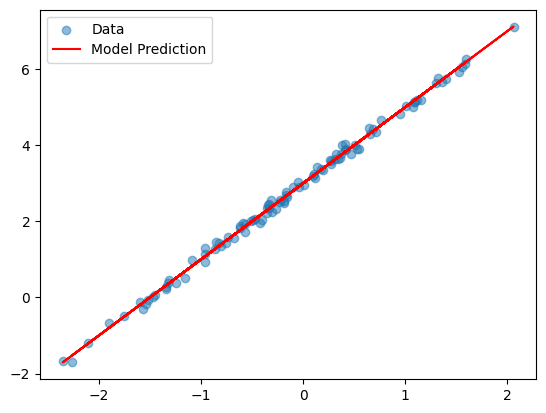

In [31]:
import matplotlib.pyplot as plt

# 1. Move to CPU and convert to NumPy
# .detach() is like saying "cut the umbilical cord to the graph"
X_cpu = X.cpu().numpy()
y_cpu = y.cpu().numpy()

with torch.no_grad():
    predictions_cpu = linear_model(X).cpu().numpy()

# 2. Plot the original "Noisy" dots
plt.scatter(X_cpu, y_cpu, label="Data", alpha=0.5)

# 3. Plot the "Learned" line
plt.plot(X_cpu, predictions_cpu, color='red', label="Model Prediction")
plt.legend()
plt.show()

In [32]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

x1 = np.array([10, 20])          # shape (2,)
x2 = np.array([[10], [20]])      # shape (2,1)

out1 = A @ x1
out2 = A @ x2

print(out1, out1.shape)
print(out2, out2.shape)

[ 50 110] (2,)
[[ 50]
 [110]] (2, 1)


In [33]:
x1 = np.array([50, 110])       # shape (2,)
x2 = np.array([[50], [110]])   # shape (2,1)

print(x1[0])     # what do you get?
print(x2[0])     # what do you get?

50
[50]


In [34]:
tensorX = torch.randn(3, 2)
tensorY = torch.randn(2, 5)

vectorX = torch.randn(3)
vectorY = torch.randn(3)

batchX = torch.randn(6, 3, 2)
batchY = torch.randn(6, 2, 5)

queryM = torch.randn(5, 3, 5)
keyM = torch.randn(5, 3, 5)
#dot product
torch.einsum('i, i->', vectorX, vectorY)

#matrix multiply
torch.einsum('ij,jk->ik', tensorX, tensorY)

#batch matrix multiply
torch.einsum('bij, bjk -> bik', batchX, batchY)

#outer product
torch.einsum('i, j->ij', vectorX, vectorY)

#attention scores
torch.einsum('bij, bkj -> bik', queryM, keyM)

tensor([[[-3.0428e+00,  3.0528e-01, -1.8381e+00],
         [ 2.4528e+00, -8.6084e-01, -1.7658e-04],
         [ 1.3394e+00,  4.2634e+00,  1.3811e+00]],

        [[-5.3160e-01, -6.0697e-01, -1.1608e-01],
         [ 2.6593e-01,  5.4745e-01, -1.0616e+00],
         [ 8.3418e-01,  1.7925e+00,  2.5972e-01]],

        [[ 9.3230e-01,  2.3067e+00,  3.3401e+00],
         [ 8.6931e-01,  1.4237e+00, -8.3511e-01],
         [ 6.4105e-01,  9.4888e-01,  2.3045e+00]],

        [[ 2.7666e+00,  8.8435e-01,  2.2359e-01],
         [ 2.0112e+00,  1.8197e+00, -1.1311e+00],
         [-4.2020e-01,  6.3623e-02,  1.2022e+00]],

        [[-1.3873e+00,  4.0330e+00,  3.3270e+00],
         [-2.1853e+00,  8.1653e-01,  2.1326e+00],
         [ 2.0961e+00,  1.2340e+00, -1.5182e+00]]])

In [35]:
randTensorX = torch.randn(3, 2)
randTensorY = torch.randn(3, 1)

print(randTensorX.shape[0])
# torch.utils.data.dataset()

class RandomDataSet(torch.utils.data.Dataset):
    def __init__(self, tensor1, tensor2):
        self.tensor1 = tensor1
        self.tensor2 = tensor2
    
    def __len__(self):
        return self.tensor1.shape[0]
    
    def __getitem__(self, index):
        return [self.tensor1[index], self.tensor2[index]]

dataSet = RandomDataSet(tensor1=randTensorX, tensor2=randTensorY)
dataLoader = torch.utils.data.DataLoader(dataSet, batch_size=2, num_workers=5, pin_memory=True)
for interation in iter(dataLoader):
    print(interation[0])
    print(interation[1])


    x = interation[0].to(device)
    y = interation[1].to(device)


3


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/lib/python3.12/multiprocessing/popen_

tensor([[ 1.2905,  0.0473],
        [-0.8661,  1.0535]])
tensor([[-0.4756],
        [ 0.0993]])
tensor([[-0.5872,  0.0411]])
tensor([[2.3352]])


In [36]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B").to("cuda")



Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [37]:
p_value = 0.9
n = 5
inputs = tokenizer("Hello, my name is", return_tensors="pt").to("cuda")
temperateValue = 0.01
for i in range(n):
    outputs = model.forward(**inputs)
    # next_token = torch.multinomial(torch.softmax((outputs.logits[0, -1, :]/temperateValue), dim=0), num_samples=1)
    sorted_result = torch.sort(torch.softmax(outputs.logits[0, -1, :], dim=0), descending=True)
    sorted_vals = sorted_result.values
    sorted_indices = sorted_result.indices
    # print(sorted_indices)
    vals = torch.cumsum(sorted_vals, dim=0) 
    mask = vals < p_value
    next_token = torch.multinomial(sorted_vals[mask==True], num_samples=1)
    # print(next_token)
    next_token = sorted_indices[next_token]
    inputs["input_ids"] = torch.cat((inputs["input_ids"], next_token.reshape(1,1)), dim=1)
    # print(type(outputs.past_key_values))
    # print(len(outputs.past_key_values))
    # print(inputs["input_ids"])
    # inputs += (output)
# outputs = model.generate(**inputs, max_new_tokens=25)
print(tokenizer.decode(inputs["input_ids"][0]))
# print(tokenizer.decode(next_token_id=))
# !nvidia-smi

Hello, my name is Jumle I first


In [38]:
import torch.nn.functional as F
seq_len = 8
vocab_size = 50
fake_logits = torch.randn(seq_len, vocab_size)
fake_targets = torch.randint(0, vocab_size, (seq_len,))
prompt_length = 3

per_token_loss = F.cross_entropy(fake_logits, fake_targets, reduction='none')
mask = torch.arange(1, seq_len+1) > prompt_length
new_per_token_loss = per_token_loss[mask]
new_per_token_loss.mean()

tensor(4.5288)

In [39]:
import gym
env = gym.make('CartPole-v1')

In [40]:
#policy network
class PolicyNetwork(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        #input to hidden
        self.input_layer = nn.Linear(4, 128)
        #hidden to output
        self.output_layer = nn.Linear(128, 2)
    def forward(self, x):
        input_forward = self.input_layer(x)
        activation = torch.relu(input_forward)
        output_forward = self.output_layer(activation)
        return output_forward.softmax(dim=-1)

In [41]:
model = PolicyNetwork()
state = torch.randn(4)
probs = model(state)
print(probs)

tensor([0.4217, 0.5783], grad_fn=<SoftmaxBackward0>)


In [43]:
new_policy = PolicyNetwork()
learning_rate = 0.3
optimizer = torch.optim.Adam(params=new_policy.parameters(), lr=1e-3)
for step in range(500):
    state = env.reset()
    done = False
    log_probs = []
    rewards = []
    entropies = []
    while not done:
        probs = new_policy(torch.tensor(state))
        action = torch.multinomial(probs, num_samples=1)
        log_prob = torch.log(probs[action.item()])
        log_probs.append(log_prob)
        entropies.append(-(probs * torch.log(probs)).sum())
        state, reward, done, info = env.step(action.item()) 
        rewards.append(reward)
    print(f"Episode {step}, reward: {sum(rewards)}")
    new_rewards = []
    for i in range(len(rewards)-1, -1, -1):
        new_rewards.append(sum(rewards[i:]))
    new_rewards = new_rewards[::-1]
    new_rewards = torch.tensor(new_rewards)
    new_rewards = new_rewards - new_rewards.mean()
    loss = sum([-log_probs[i] * new_rewards[i] for i in range(len(rewards))])
    beta = 0.01
    loss = loss - beta * sum(entropies)
    
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

Episode 0, reward: 25.0
Episode 1, reward: 26.0
Episode 2, reward: 20.0
Episode 3, reward: 10.0
Episode 4, reward: 39.0
Episode 5, reward: 14.0
Episode 6, reward: 27.0
Episode 7, reward: 29.0
Episode 8, reward: 27.0
Episode 9, reward: 17.0
Episode 10, reward: 13.0
Episode 11, reward: 28.0
Episode 12, reward: 15.0
Episode 13, reward: 10.0
Episode 14, reward: 22.0
Episode 15, reward: 39.0
Episode 16, reward: 15.0
Episode 17, reward: 21.0
Episode 18, reward: 12.0
Episode 19, reward: 19.0
Episode 20, reward: 18.0
Episode 21, reward: 15.0
Episode 22, reward: 38.0
Episode 23, reward: 15.0
Episode 24, reward: 13.0
Episode 25, reward: 30.0
Episode 26, reward: 10.0
Episode 27, reward: 36.0
Episode 28, reward: 18.0
Episode 29, reward: 16.0
Episode 30, reward: 17.0
Episode 31, reward: 25.0
Episode 32, reward: 16.0
Episode 33, reward: 30.0
Episode 34, reward: 35.0
Episode 35, reward: 30.0
Episode 36, reward: 24.0
Episode 37, reward: 57.0
Episode 38, reward: 36.0
Episode 39, reward: 17.0
Episode 40

In [51]:
def isPrime(x: int) -> bool:
    for i in range(2, x):
        if x % i == 0:
            return 0
    return 1
def reward(results):
    return torch.tensor([isPrime(x) for x in results]) 

In [ ]:
logits = torch.zeros(101, requires_grad=True)  # never overwrite this
learning_rate = 1e-2
optimizer = torch.optim.Adam(params=[logits], lr=learning_rate)#training loop
for step in range(1000):
    probs = torch.softmax(logits, dim=0)            # compute this fresh each step
    samples = torch.multinomial(probs, num_samples=8)
    rewards = reward(samples).float()
    raw_rewards = reward(samples).float()
    if step % 100 == 0:
        print(f"step {step}, avg reward: {raw_rewards.mean().item():.3f}")
    rewards = (rewards - rewards.mean()) / (rewards.std(dim=0) + 1e-4)
    log_probs = torch.log(probs[samples])
    # print(rewards)
    # print(log_probs)
    loss = -1*sum(log_probs*rewards)
    # print(rewards.mean())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



1
